In [ ]:
# Import packages
import numpy as np
import scipy
import scipy.sparse as sp
import matplotlib.pyplot as plt

# **Define Functions**

## **MPS Operations**

In [ ]:
def compute_bond_dims(N, d, D):
  """
    Computes an array that stores the bond dimension across each bond. For an MPS
    on an open system, the bond dimension starts at 2 at the edges, increases
    exponentially moving into the bulk, and saturates at the maximum bond
    dimension D.

    Args:
    - N: Number of sites.
    - d: Physical dimension.
    - D: (Maximum) bond dimension.

    Returns:
    - bond_dims: An array that stores the bond dimensions across each site in
      the spin chain. This array is indexed such that bond_dims[site] is the
      bond dimension across the (site, site+1) bond.
    """

  bond_dims = np.zeros(N-1)
  for site in range(N-1):
    if site <= (N//2-1):
      # Left half of the spin chain
      bond_dims[site] = min(d**(site+1), D)
    else:
      # Right half of the spin chain
      bond_dims[site] = min(d**(N-1-site), D)

  bond_dims = bond_dims.astype(int)

  return bond_dims



def mps_norm(A, bond_dims):
    """
    Computes the norm of an MPS, following the inner product algorithm described in https://tensornetwork.org/mps/

    Args:
    - A: An array of the tensors comprising the MPS, indexed as (batch, site, left bond, physical, right bond).
    - bond_dims: An array that stores the bond dimensions across each site

    Returns:
    - norm: The norm of the MPS (a scalar).
    """

    N_batch, N, D, d, _ = A.shape

    # Initialize contraction by contracting physical dimension of first tensor
    Dr = bond_dims[0]
    contraction = np.einsum('zkl,zkm->zlm', np.conjugate(A[:,0,0,:,:Dr]), A[:,0,0,:,:Dr])     # batch, upper right, lower right

    # Contract against subsequent tensors
    for site in range(1, N-1):
      Dl = bond_dims[site-1]
      Dr = bond_dims[site]
      tensor = A[:, site, :Dl, :, :Dr]
      contraction = contract_mps_tensors(contraction, tensor)

    # Contract against last tensors
    Dl = bond_dims[N-2]
    contraction = np.einsum('zlm,zln,zmn->z', contraction, np.conjugate(A[:,-1,:Dl,:,0]), A[:,-1,:Dl,:,0])
    norm = np.sqrt(contraction)

    return norm



def contract_mps_tensors(contraction, tensor):
    """
    Contracts 'contraction' against an adjacent tensor 'tensor' in computing the norm of an MPS.
    This function is equivalent to
      contraction = np.einsum('zlm,zmno->zlno', contraction, tensor)
      contraction = np.einsum('zlno,zlnq->zqo', contraction, np.conjugate(tensor))
    but we replace np.einsum with np.matmul for faster computation

    Args:
    - contraction: A tensor representing an intermeidate contraction of an MPS,
      indexed as (batch, upper right, lower right).
    - tensor: a single site tensor, indexed as (batch, left bond, physical, right bond).

    Returns:
    - contraction: The updated contraction tensor.
    """

    # Contract against left bond dimension of bottom tensor
    C_dims = contraction.shape
    T_dims = tensor.shape
    tensor_mat = tensor.reshape(T_dims[0], T_dims[1], T_dims[2]*T_dims[3])
    tmp = np.matmul(contraction, tensor_mat)
    tmp = tmp.reshape(C_dims[0], C_dims[1], T_dims[2], T_dims[3])

    # Contract against left bond dimension and physical dimension of top tensor
    tmp_mat = tmp.reshape(C_dims[0], C_dims[1]*T_dims[2], T_dims[3])
    tensor_conj_mat = np.conjugate(tensor).reshape(T_dims[0], T_dims[1]*T_dims[2], T_dims[3])
    contraction = np.matmul(tmp_mat.transpose(0, 2, 1), tensor_conj_mat).transpose(0, 2, 1)

    return contraction



def left_canonicalize(A, bond_dims, site):
    """
    Left-canonicalizes at site, and move orthogonality center to site+1.
    Requires site <= N-2.

    Args:
    - A: An array of the tensors comprising the MPS, indexed as (batch, site, left bond, physical, right bond).
    - bond_dims: An array that stores the bond dimensions across each site.
    - site: The site to canonicalize at.

    Returns:
    - A: Updated array of tensors
    """

    N_batch, N, D, d, _ = A.shape

    # Determine bond dimensions
    if site == 0:
      Dl = 1
    else:
      Dl = bond_dims[site-1]
    Dr = bond_dims[site]

    # Perform QR decomposition
    M = A[:, site, :Dl, : ,:Dr].reshape(N_batch, Dl * d, Dr)
    Q, R = np.linalg.qr(M, mode='reduced')

    # Update tensor at site
    A[:, site, :Dl,: ,:Dr] = Q.reshape(N_batch, Dl, d, Dr)

    # Push R into tensor at site+1
    Dl2 = bond_dims[site]
    if site == N-2:
      Dr2 = 1
    else:
      Dr2 = bond_dims[site+1]
    A_tensor_tmp = A[:, site + 1, :Dl2, : ,:Dr2].reshape(N_batch, Dl2, d*Dr2)
    new_tensor = np.matmul(R, A_tensor_tmp).reshape(N_batch, Dl2, d, Dr2)
    A[:, site + 1, :Dl2, : ,:Dr2] = new_tensor

    return A



def right_canonicalize(A, bond_dims, site):
    """
    Right-canonicalizes at site, and move orthogonality center to site-1.
    Requires site >= 1.

    Args:
    - A: An array of the tensors comprising the MPS, indexed as (batch, site, left bond, physical, right bond).
    - bond_dims: An array that stores the bond dimensions across each site.
    - site: The site to canonicalize at.

    Returns:
    - A: Updated array of tensors
    """

    N_batch, N, D, d, _ = A.shape

    # Determine bond dimensions
    Dl = bond_dims[site-1]
    if site == N-1:
      Dr = 1
    else:
      Dr = bond_dims[site]

    # Perform QR decomposition
    M = A[:, site, :Dl, : ,:Dr].reshape(N_batch, Dl, d * Dr)
    Q, R = np.linalg.qr(M.transpose(0,2,1), mode='reduced')
    Q_T = Q.transpose(0,2,1)
    R_T = R.transpose(0,2,1)

    # Update tensor at site
    A[:, site, :Dl, : ,:Dr] = Q_T.reshape(N_batch, Dl, d, Dr)

    # Push R into tensor at site-1
    if site == 1:
      Dl2 = 1
    else:
      Dl2 = bond_dims[site-2]
    Dr2 = bond_dims[site-1]
    A_tensor_tmp = A[:, site - 1, :Dl2, : ,:Dr2].reshape(N_batch, Dl2*d, Dr2)
    new_tensor = np.matmul(A_tensor_tmp, R_T).reshape(N_batch, Dl2, d, Dr2)
    A[:, site - 1, :Dl2, : ,:Dr2] = new_tensor

    return A



def left_canonicalize_to(A, bond_dims, center):
    """
    Left-canonicalize sites 0 ... center-1. Leaves orthogonality center at center.

    Args:
    - A: An array of the tensors comprising the MPS, indexed as (batch, site, left bond, physical, right bond).
    - bond_dims: An array that stores the bond dimensions across each site.
    - center: The desired orthogonality center

    Returns:
    - A: Updated array of tensors
    """

    for site in range(center):
        A = left_canonicalize(A, bond_dims, site)

    return A



def right_canonicalize_from(A, bond_dims, center):
    """
    Right-canonicalize sites N-1 ... center+1. Leaves orthogonality center at center.

    Args:
    - A: An array of the tensors comprising the MPS, indexed as (batch, site, left bond, physical, right bond).
    - bond_dims: An array that stores the bond dimensions across each site.
    - center: The desired orthogonality center

    Returns:
    - A: Updated array of tensors
    """

    for site in range(N-1, center, -1):
        A = right_canonicalize(A, bond_dims, site)

    return A



def mixed_canonicalize(A, bond_dims, center):
    """
    Puts MPS into mixed canonical form, with orthogonality center at center.
    center can range from 0 to N-1

    Args:
    - A: An array of the tensors comprising the MPS, indexed as (batch, site, left bond, physical, right bond).
    - bond_dims: An array that stores the bond dimensions across each site.
    - center: The desired orthogonality center

    Returns:
    - A: Updated array of tensors
    """

    # Left canonicalize up to center
    A2 = left_canonicalize_to(A, bond_dims, center)
    A = A2.copy()

    # Right canonicalize up to center
    A2 = right_canonicalize_from(A, bond_dims, center)
    A = A2.copy()

    return A



def mps_state_vec(A, bond_dims):
    """
    Explicitly calculate the state vector represented by the MPS

    Args:
    - A: An array of the tensors comprising the MPS, indexed as (batch, site, left bond, physical, right bond).
    - bond_dims: An array that stores the bond dimensions across each site.

    Returns:
    - mps_vec: The state vector of the MPS.
    """

    N_batch, N, D, d, _ = A.shape

    # Starts calculating the corresponding state vector
    Dr1 = bond_dims[0]
    Dl2 = bond_dims[0]
    Dr2 = bond_dims[1]
    mps_vec = np.einsum('zkl,zlmn->zkmn', A[:,0,0,:,:Dr1], A[:,1,:Dl2,:,:Dr2])        # batch, left physical, right physical, right bond
    mps_vec = np.reshape(mps_vec, (N_batch, d**2, Dr2))

    # Contract against subsequent tensors
    for site in range(2, N - 1):
      Dl = bond_dims[site-1]
      Dr = bond_dims[site]
      tensor = A[:,site,:Dl,:,:Dr]
      mps_vec = np.einsum('zkl,zlmn->zkmn', mps_vec, tensor)                     # batch, left physical, right physical, right bond
      mps_vec = np.reshape(mps_vec, (N_batch, d**(site+1), Dr))

    # Contract against last tensor
    Dl = bond_dims[N-2]
    mps_vec = np.einsum('zkl,zlm->zkm', mps_vec, A[:,-1,:Dl,:,0])
    mps_vec = np.reshape(mps_vec, (N_batch, d**N))

    return mps_vec



def apply_one_site_operation(U, site, A):
    """
    Apply a one-site operation U to the tensor at site

    Args:
    - U: The d-dimensional matrix representing the operation that acts on a single site.
    - site: The site at which the operation is applied.
    - A: An array of the tensors comprising the MPS, indexed as (site, left bond, physical, right bond).

    Returns:
    - A2: Updated tensors
    """

    # Contract U against the tensor at site i
    # This is equivalent to A2[:,site,:,:,:] = np.einsum('zijk,jl->zilk', A[:,site,:,:,:], U)
    A2 = A.copy()
    A_tensor_tmp = A[:,site,:,:,:].transpose(0,1,3,2)
    new_tensor = np.matmul(A_tensor_tmp, U).transpose(0,1,3,2)
    A2[:,site,:,:,:] = new_tensor

    return A2



def apply_two_site_operation(U, site, A, bond_dims):
    """
    Apply a two-site operation U to two adjacent tensors at sites (site, site+1) in an MPS.
    site must take an integer value in the range [0, N-2] to be valid.

    Args:
    - U: The d**2-dimensional matrix representing the operation that acts on two sites.
    - site: site of operation to be applied.
    - A: An array of the tensors comprising the MPS, indexed as (batch, site, left bond, physical, right bond).
    - bond_dims: An array that stores the bond dimensions across each site.

    Returns:
    - A2: Updated tensors
    """

    N_batch, N, D, d, _ = A.shape

    # Determine relevant bond dimensions
    if site == 0:
      Dl1 = 1
    else:
      Dl1 = bond_dims[site-1]
    Dr1 = bond_dims[site]

    Dl2 = bond_dims[site]
    if site == N-2:
      Dr2 = 1
    else:
      Dr2 = bond_dims[site+1]

    # Combine adjacent tensors at site (site, site+1)
    tensor1 = A[:, site, :Dl1, :, :Dr1]
    tensor2 = A[:, site+1, :Dl2, :, :Dr2]
    # This is equivalent to combined_A = np.einsum('zjkl,zlmn->zjkmn', tensor1, tensor2)
    combined_A = np.matmul(tensor1.reshape(N_batch, Dl1*d, Dr1), tensor2.reshape(N_batch, Dl2, d*Dr2))
    combined_A = combined_A.reshape(N_batch, Dl1, d, d, Dr2)            # batch, left bond dim, left physical dim, right physical dim, right bond dim


    # Apply U to the combined tensor
    combined_A = combined_A.reshape(N_batch, Dl1, d**2, Dr2)            # batch, left bond dim, physical dims, right bond dim
    # This is equivalent to combined_A = np.einsum('qp,zjpn->zjqn', U, combined_A)
    combined_A = np.matmul(combined_A.transpose(0,1,3,2), U.transpose(1,0)).transpose(0,1,3,2)
    combined_A = combined_A.reshape(N_batch, Dl1, d, d, Dr2)            # batch, left bond dim, left physical dim, right physical dim, right bond dim


    # Perform SVD
    combined_A = combined_A.reshape(N_batch, Dl1*d, d*Dr2)               # batch, left bond dim*left physical dim, right physical dim*right bond dim
    U_svd, S_svd, Vh_svd = np.linalg.svd(combined_A, full_matrices=False)


    # Truncate and define new tensors
    left_tensor_new = U_svd[:,:,:Dr1].reshape(N_batch, Dl1, d, Dr1)       # batch, left bond dim, physical dims, right bond dim
    right_tensor_new = Vh_svd[:,:Dl2,:].reshape(N_batch, Dl2, d, Dr2)     # batch, left bond dim, physical dims, right bond dim
    S_new = S_svd[:, :Dr1]
    left_tensor_new *= S_new[:,None,None,:]                               # Leaves i as the orthogonality center


    # Assign new tensors to the MPS
    A2 = A.copy()
    A2[:, site, :Dl1, :, :Dr1] = left_tensor_new
    A2[:, site+1, :Dl2, :, :Dr2] = right_tensor_new

    return A2



def apply_four_site_operation(U, site, A, bond_dims):
    """
    Apply a four-site operation to four adjacent tensors at sites (site, site+1, site+2, site+3) in an MPS.

    Args:
    - U: The d**4-dimensional matrix representing the operation that acts on two sites.
    - site: site of operation to be applied.
    - A: An array of the tensors comprising the MPS, indexed as (site, left bond, physical, right bond).
    - bond_dims: An array that stores the bond dimensions across each site.

    Returns:
    - A2: Updated tensors
    """

    N_batch, N, D, d, _ = A.shape

    # Determine bond dimensions across sites to be contracted
    if site == 0:
      Dl1 = 1
    else:
      Dl1 = bond_dims[site-1]
    Dr1 = bond_dims[site]

    Dl2 = bond_dims[site]
    Dr2 = bond_dims[site+1]

    Dl3 = bond_dims[site+1]
    Dr3 = bond_dims[site+2]

    Dl4 = bond_dims[site+2]
    if site == N-4:
      Dr4 = 1
    else:
      Dr4 = bond_dims[site+3]


    # Combine adjacent tensors at site (site, site+1, site+2, site+3)
    tensor1 = A[:, site, :Dl1, :, :Dr1]
    tensor2 = A[:, site+1, :Dl2, :, :Dr2]
    tensor3 = A[:, site+2, :Dl3, :, :Dr3]
    tensor4 = A[:, site+3, :Dl4, :, :Dr4]
    #This is equivalent to combined_A = np.einsum('zjkl,zlmn,znop,zpqr->zjkmoqr', tensor1, tensor2, tensor3, tensor4)
    tensor_tmp = np.matmul(tensor1.reshape(N_batch, Dl1*d, Dr1), tensor2.reshape(N_batch, Dl2, d*Dr2))
    tensor_tmp = tensor_tmp.reshape(N_batch, Dl1, d**2, Dr2)
    tensor_tmp = np.matmul(tensor_tmp.reshape(N_batch, Dl1*d**2, Dr2), tensor3.reshape(N_batch, Dl3, d*Dr3))
    tensor_tmp = tensor_tmp.reshape(N_batch, Dl1, d**3, Dr3)
    tensor_tmp = np.matmul(tensor_tmp.reshape(N_batch, Dl1*d**3, Dr3), tensor4.reshape(N_batch, Dl4, d*Dr4))
    combined_A = tensor_tmp.reshape(N_batch, Dl1, d**4, Dr4)


    # Apply U to the combined tensor
    combined_A = combined_A.reshape(N_batch, Dl1, d**4, Dr4)                    # batch, left bond dim, physical dims, right bond dim
    # This is equivalent to combined_A = np.einsum('qp,zjpn->zjqn', U, combined_A)
    combined_A = np.matmul(combined_A.transpose(0,1,3,2), U.transpose(1,0)).transpose(0,1,3,2)
    combined_A = combined_A.reshape(N_batch, Dl1, d**4, Dr4)                    # batch, left bond dim, left physical dim, right physical dim, right bond dim


    # Perform SVD in the middle
    combined_A = combined_A.reshape(N_batch, Dl1*d**2, d**2*Dr4)                # batch, left bond dim*left physical dim, right physical dim*right bond dim
    U_svd_mid, S_svd_mid, Vh_svd_mid = np.linalg.svd(combined_A, full_matrices=False)


    # Truncate and define new tensors (left_tensor and right_tensor)
    left_tensor = U_svd_mid[:,:,:Dr2].reshape(N_batch, Dl1, d, d, Dr2)          # batch, left bond dim, physical dims, right bond dim
    S2_new = S_svd_mid[:,:Dr2]
    right_tensor = Vh_svd_mid[:, :Dl3, :].reshape(N_batch, Dl3, d, d, Dr4)

    # Equally absorb singular values into left_tensor and right_tensor
    left_tensor *= np.sqrt(S2_new)[:, None, None, None, :]
    right_tensor *= np.sqrt(S2_new)[:, :, None, None, None]


    # Perform SVD again on left tensor
    left_tensor = left_tensor.reshape(N_batch, Dl1*d, d*Dr2)
    U_svd_left, S_svd_left, Vh_svd_left = np.linalg.svd(left_tensor, full_matrices=False)

    # Truncate and define new tensors
    tensor1_new = U_svd_left[:,:,:Dr1].reshape(N_batch, Dl1, d, Dr1)
    S1_new = S_svd_left[:,:Dr1]
    tensor2_new = Vh_svd_left[:, :Dl2, :].reshape(N_batch, Dl2, d, Dr2)
    tensor2_new *= S1_new[:, :, None, None]                                     # Absorb singular values into tensor2_new


    # Perform SVD on right tensor
    right_tensor = right_tensor.reshape(N_batch, Dl3*d, d*Dr4)
    U_svd_right, S_svd_right, Vh_svd_right = np.linalg.svd(right_tensor, full_matrices=False)

    # Truncate and define new tensors
    tensor3_new = U_svd_right[:,:,:Dr3].reshape(N_batch, Dl3, d, Dr3)
    S3_new = S_svd_right[:,:Dr3]
    tensor3_new *= S3_new[:, None, None, :]                                     # Absorb singular values into tensor3_new
    tensor4_new = Vh_svd_right[:, :Dl4, :].reshape(N_batch, Dl4, d, Dr4)


    # Assign new tensors to the MPS
    A2 = A.copy()
    A2[:, site, :Dl1, :, :Dr1] = tensor1_new
    A2[:, site+1, :Dl2, :, :Dr2] = tensor2_new
    A2[:, site+2, :Dl3, :, :Dr3] = tensor3_new
    A2[:, site+3, :Dl4, :, :Dr4] = tensor4_new

    return A2



def mps_one_site_obs(obs, i, A, bond_dims):
    """
    Computes expectation value of obs at site i in an MPS

    Args:
    - obs: The 1-site observable
    - i: site of obs
    - A: An array of the tensors comprising the MPS, indexed as (batch, site, left bond, physical, right bond).
    - bond_dims: An array that stores the bond dimensions across each site.

    Returns:
    - val: The expectation value of the observable
    """

    N_batch, N, D, d, _ = A.shape

    # Create cap tensor that projects out the relevant values of the leftmost/rightmost sites
    cap = np.zeros((N_batch, 1, 1), dtype=complex) # batch, top bond dim, bottom bond dim
    cap[:, 0, 0] = 1


    # Initialize contraction
    contraction = cap


    # Contract against subsequent tensors until site i
    for site in range(0, i):
      if site == 0:
        Dl = 1
      else:
        Dl = bond_dims[site-1]
      Dr = bond_dims[site]

      tensor = A[:, site, :Dl, :, :Dr]
      contraction = contract_mps_tensors(contraction, tensor)


    # Contract against tensor and observable at site i
    if i == 0:
      Dl = 1
    else:
      Dl = bond_dims[i-1]
    if i == N-1:
      Dr = 1
    else:
      Dr = bond_dims[i]

    tensor = A[:, i, :Dl, :, :Dr]
    # This is equivalent to tensor_obs = np.einsum('zmno,np->zmpo', tensor, obs)
    tensor_obs = np.matmul(tensor.transpose(0,1,3,2), obs).transpose(0,1,3,2)

    # Contract against left bond dimension of bottom tensor (tensor_obs)
    # This is equivalent to contraction = np.einsum('zlm,zmno->zlno', contraction, tensor_obs)
    dims = tensor_obs.shape
    contraction = np.matmul(contraction, tensor_obs.reshape(dims[0], dims[1], dims[2]*dims[3]))
    contraction = contraction.reshape(contraction.shape[0], contraction.shape[1], dims[2], dims[3])   # upper right, physical, lower right

    # Contract against left bond dimension and physical dimension of top tensor
    # This is equivalent to contraction = np.einsum('zlno,zlnq->zqo', contraction, np.conjugate(tensor))
    C_dims = contraction.shape
    tmp_contraction = contraction.reshape(C_dims[0], C_dims[1]*C_dims[2], C_dims[3])
    T_dims = tensor.shape
    tmp_conj_tensor = np.conjugate(tensor).reshape(T_dims[0], T_dims[1]*T_dims[2], T_dims[3])
    contraction = np.matmul(tmp_contraction.transpose(0, 2, 1), tmp_conj_tensor).transpose(0, 2, 1)   # upper right, lower right


    # Contract against subsequent tensors after site i
    for site in range(i+1, N):
      Dl = bond_dims[site-1]
      if site == N-1:
        Dr = 1
      else:
        Dr = bond_dims[site]

      tensor = A[:, site, :Dl, :, :Dr]
      contraction = contract_mps_tensors(contraction, tensor)


    # Contract against final cap
    contraction = np.einsum('zlm,zlm->z', contraction, cap)
    val = contraction

    return val



def mps_two_site_obs(obs, i, A, bond_dims):
    """
    Computes expectation value of obs at site i in an MPS

    Args:
    - obs: The 2-site observable
    - i: site of obs
    - A: An array of the tensors comprising the MPS, indexed as (batch, site, left bond, physical, right bond).
    - bond_dims: An array that stores the bond dimensions across each site.

    Returns:
    - val: The expectation value of the observable
    """

    N_batch, N, D, d, _ = A.shape

    # Create cap tensor that projects out the relevant values of the leftmost/rightmost sites
    cap = np.zeros((N_batch, 1, 1), dtype=complex) # batch, top bond dim, bottom bond dim
    cap[:, 0, 0] = 1


    # Initialize contraction
    contraction = cap


    # Contract against subsequent tensors until site i
    for site in range(0, i):
      if site == 0:
        Dl = 1
      else:
        Dl = bond_dims[site-1]
      Dr = bond_dims[site]

      tensor = A[:, site, :Dl, :, :Dr]
      contraction = contract_mps_tensors(contraction, tensor)


    # Contract against tensor and observable at site i
    if i == 0:
      Dl1 = 1
    else:
      Dl1 = bond_dims[i-1]
    Dr1 = bond_dims[i]

    Dl2 = bond_dims[i]
    if i == N-2:
      Dr2 = 1
    else:
      Dr2 = bond_dims[i+1]

    # Combine mps tensor and contract observable against tensor
    tensor1 = A[:, i, :Dl1, :, :Dr1]
    tensor2 = A[:, i+1, :Dl2, :, :Dr2]
    #combined_tensor = np.einsum('zabc,zcde->zabde', tensor1, tensor2)
    combined_tensor = np.matmul(tensor1.reshape(N_batch, Dl1*d, Dr1), tensor2.reshape(N_batch, Dl2, d*Dr2))   # batch, left bond dim, left physical dim, right physical dim, right bond dim

    combined_tensor = combined_tensor.reshape(N_batch, Dl1, d**2, Dr2)                        # batch, left bond dim, physical dims, left physical dim
    # This is equivalent to combined_tensor_obs = np.einsum('zabe,bf->zafe', combined_tensor, obs)
    combined_tensor_obs = np.matmul(combined_tensor.transpose(0,1,3,2), obs).transpose(0,1,3,2)

    # Contract against left bond dimension of bottom tensor (combined_tensor_obs)
    # This is equivalent to contraction = np.einsum('zlm,zmno->zlno', contraction, combined_tensor_obs)
    dims = combined_tensor_obs.shape
    contraction = np.matmul(contraction, combined_tensor_obs.reshape(dims[0], dims[1], dims[2]*dims[3]))
    contraction = contraction.reshape(contraction.shape[0], contraction.shape[1], dims[2], dims[3])     # upper right, physical, lower right

    # Contract against left bond dimension and physical dimension of top tensor (combined_tensor)
    # This is equivalent to contraction = np.einsum('zlno,zlnq->zqo', contraction, np.conjugate(combined_tensor))
    C_dims = contraction.shape
    tmp_contraction = contraction.reshape(C_dims[0], C_dims[1]*C_dims[2], C_dims[3])
    T_dims = combined_tensor.shape
    tmp_conj_combined_tensor = np.conjugate(combined_tensor).reshape(T_dims[0], T_dims[1]*T_dims[2], T_dims[3])
    contraction = np.matmul(tmp_contraction.transpose(0, 2, 1), tmp_conj_combined_tensor).transpose(0, 2, 1)    # upper right, lower right


    # Contract against subsequent tensors after site i
    for site in range(i+2, N):
      Dl = bond_dims[site-1]
      if site == N-1:
        Dr = 1
      else:
        Dr = bond_dims[site]

      tensor = A[:, site, :Dl, :, :Dr]
      contraction = contract_mps_tensors(contraction, tensor)


    # Contract against final cap
    contraction = np.einsum('zlm,zlm->z', contraction, cap)
    val = contraction

    return val



def Compute_Observables(A, bond_dims, J):
  """
  Computes the observables that we track during time evolution.
  These are energy, a jump operator correlation function, occupation number,
  and number occupation correlation

  Args:
  - A: An array of the tensors comprising the MPS, indexed as (batch, site, left bond, physical, right bond).
  - bond_dims: An array that stores the bond dimensions across each site.
  - J: Interaction strength of Bose-Hubbard Hamiltonian.

  Returns:
  - vals: An array of the the expectation values:
    Energy, corr (a_{N/2}^dag*a_{N/2+1} + h.c.), num1 (n_{N/2}), num2 (n_{N/2+1}), num_num_final (n_{N/2}*n_{N/2+1}).
  """

  N = A.shape[1]

  # Defines annihilation/creation operators, correlation function, number operators
  a = np.array([[0,1],
                [0,0]], dtype=complex)
  a_dag = np.conjugate(np.transpose(a))
  num = a_dag @ a
  num_num = np.kron(num, num)
  corr = np.kron(a, a_dag)

  # Energy
  E_val = 0
  for i in range(0, N-1):
    E_val += mps_two_site_obs(corr, i, A, bond_dims)
  E_val += np.conjugate(E_val)
  E_val *= -J

  # Correlation function
  corr_val = mps_two_site_obs(corr, N//2-1, A, bond_dims)
  corr_val += np.conjugate(corr_val)

  # Number operators
  num1_val = mps_one_site_obs(num, N//2-1, A, bond_dims)
  num2_val = mps_one_site_obs(num, N//2, A, bond_dims)

  # Number-number correlation
  num_num_val = mps_two_site_obs(num_num, N//2-1, A, bond_dims)

  # All the expectation values compiled together
  vals = np.stack((E_val, corr_val, num1_val, num2_val, num_num_val), axis=0)    # indexed as (observable, trajectory)

  # Normalize the expectation values by the norm of the mps
  norm = mps_norm(A, bond_dims)**2
  vals *= 1/norm[None,:]

  return vals

## **TEBD Functions**

In [ ]:
def tebd1_step(A, bond_dims, Us):
    """
    Perform a single 1st order TEBD time step on an MPS.

    Args:
    - A: An array of the tensors comprising the MPS, indexed as (batch, site, left bond, physical, right bond).
    - bond_dims: An array that stores the bond dimensions across each site.
    - Us: the infinitesimal time step under 2-site local Hamiltonian terms (i.e., U = e^{-i*h*Delta_t})

    Returns:
    - A: Updated tensors
    """

    # We assume that the input MPS has its orthognality center set at site=0

    # Apply unitaries to even sites
    for site in range(0, N-1, 2):
      A = apply_two_site_operation(Us[site], site, A, bond_dims)
      if site < N-2:
        A = left_canonicalize(A, bond_dims, site)
        A = left_canonicalize(A, bond_dims, site+1)

    # Orthogonality center is now at N-2, move it to N-1
    A = right_canonicalize(A, bond_dims, N-2)

    # Apply unitaries to odd sites
    for site in range(N-3, 0, -2): #reversed(range(1, N-1, 2)):
      A = apply_two_site_operation(Us[site], site, A, bond_dims)
      if site > 1:
        A = right_canonicalize(A, bond_dims, site)
        A = right_canonicalize(A, bond_dims, site-1)

    # Orthogonality center now at 1, move it to 0
    A = right_canonicalize(A, bond_dims, 1)

    return A


def tebd1(A, bond_dims, hs, t, r):
    """
    Perform time evolution up to time t using 1st order TEBD with r time steps on an MPS.

    Args:
    - A: An array of the tensors comprising the MPS, indexed as (site, left bond, physical, right bond).
    - bond_dims: An array that stores the bond dimensions across each site.
    - hs: the 2-site local Hamiltonian terms
    - t: total evolution time
    - r: number of time steps

    Returns:
    - A_up: Updated tensors
    """

    # Defines time step and infinitesimal time evolution under 2-site local Hamiltonian terms
    Delta_t = t/r
    Us = scipy.linalg.expm(-1j*hs*Delta_t)

    # Performs TEBD
    A_up = A.copy()       # updated copy
    A_up = mixed_canonicalize(A_up, bond_dims, 0)   # Set orthogonality center to 0

    for _ in range(r):
      A_up = tebd1_step(A_up, bond_dims, Us)

    return A_up


def tebd2_step(A, bond_dims, Us, Us_Half):
    """
    Perform a single 2nd order TEBD time step on an MPS.

    Args:
    - A: An array of the tensors comprising the MPS, indexed as (site, left bond, physical, right bond).
    - bond_dims: An array that stores the bond dimensions across each site.
    - Us_Half: One half infinitesimal time step under 2-site local Hamiltonian term (i.e., U = e^{-i*h*Delta_t/2})
    - Us: Infinitesimal time step under 2-site local Hamiltonian term (i.e., U = e^{-i*h*Delta_t})

    Returns:
    - A: Updated tensors
    """

    # Apply half unitaries to even sites
    for site in range(0, N-1, 2):
      A = apply_two_site_operation(Us_Half[site], site, A, bond_dims)
      if site < N-2:
        A = left_canonicalize(A, bond_dims, site)
        A = left_canonicalize(A, bond_dims, site+1)

    # Orthogonality center is now at N-2, move it to N-1
    A = right_canonicalize(A, bond_dims, N-2)

    # Apply unitaries to odd sites
    for site in range(N-3, 0, -2): #reversed(range(1, N-1, 2)):
      A = apply_two_site_operation(Us[site], site, A, bond_dims)
      if site > 1:
        A = right_canonicalize(A, bond_dims, site)
        A = right_canonicalize(A, bond_dims, site-1)

    # Orthogonality center now at 1, move it to 0
    A = right_canonicalize(A, bond_dims, 1)

    # Apply half unitaries to even sites
    for site in range(0, N-1, 2):
      A = apply_two_site_operation(Us_Half[site], site, A, bond_dims)
      if site < N-2:
        A = left_canonicalize(A, bond_dims, site)
        A = left_canonicalize(A, bond_dims, site+1)

    # Orthogonality center is now at N-2, move it back to 0
    A = mixed_canonicalize(A, bond_dims, 0)

    return A



def tebd2(A, bond_dims, hs, t, r):
    """
    Perform time evolution to time t using 2nd order TEBD with r time steps on an MPS.

    Args:
    - A: An array of the tensors comprising the MPS, indexed as (site, left bond, physical, right bond).
    - bond_dims: An array that stores the bond dimensions across each site.
    - hs: the 2-site local Hamiltonian terms
    - t: total evolution time
    - r: number of time steps

    Returns:
    - A_up: Updated tensors
    """

    # Defines time step and infinitesimal time evolution under 2-site local Hamiltonian terms
    Delta_t = t/r
    Us = scipy.linalg.expm(-1j*hs*Delta_t)
    Us_Half = scipy.linalg.expm(-1j*hs*Delta_t/2)

    # Performs TEBD
    A_up = A.copy()       # updated copy
    A_up = mixed_canonicalize(A_up, bond_dims, 0)   # Set orthogonality center to 0

    for _ in range(r):
      A_up = tebd2_step(A_up, bond_dims, Us, Us_Half)

    return A_up



def tebd4_step(A, bond_dims, Us_p, Us_Half_p, Us_1Minus4p, Us_Half_1Minus4p):
    """
    Perform a single 4th order TEBD time step on an MPS.

    Args:
    - A: An array of the tensors comprising the MPS, indexed as (site, left bond, physical, right bond).
    - bond_dims: An array that stores the bond dimensions across each site.
    - Us_p: Infinitesimal time step under 2-site local Hamiltonian term (i.e., U = e^{-i*h*Delta_t})
    - Us_Half_p: One half infinitesimal time step under 2-site local Hamiltonian term (i.e., U = e^{-i*h*p_k*Delta_t/2})
    - Us_1Minus4p: Infinitesimal time step under 2-site local Hamiltonian term (i.e., U = e^{-i*h*(1-4*p_k)*Delta_t})
    - Us_Half_1Minus4p: One half infinitesimal time step under 2-site local Hamiltonian term (i.e., U = e^{-i*h*(1-4*p_k)*Delta_t/2})

    Returns:
    - A: Updated tensors
    """

    # Performs the TEBD time step by calling 2nd order TEBD, as per the recursive construction of higher order Suzuki-Trotter
    A = tebd2_step(A, bond_dims, Us_p, Us_Half_p)
    A = tebd2_step(A, bond_dims, Us_p, Us_Half_p)
    A = tebd2_step(A, bond_dims, Us_1Minus4p, Us_Half_1Minus4p)
    A = tebd2_step(A, bond_dims, Us_p, Us_Half_p)
    A = tebd2_step(A, bond_dims, Us_p, Us_Half_p)

    return A



def tebd4(A, bond_dims, hs, t, r):
    """
    Perform time evolution to time t using 4th order TEBD with r time steps on an MPS.

    Args:
    - A: An array of the tensors comprising the MPS, indexed as (site, left bond, physical, right bond).
    - bond_dims: An array that stores the bond dimensions across each site.
    - hs: the 2-site local Hamiltonian terms
    - t: total evolution time
    - r: number of time steps

    Returns:
    - A_up: Updated tensors
    """

    # Defines time step and the ratio p_4 used in 4th order Trotterization
    Delta_t = t/r
    p_4 = 1/(4-4**(1/3))

    # Defines infinitesimal time steps
    Us_p = scipy.linalg.expm(-1j*hs*p_4*Delta_t)
    Us_Half_p = scipy.linalg.expm(-1j*hs*p_4*Delta_t/2)
    Us_1Minus4p = scipy.linalg.expm(-1j*hs*(1-4*p_4)*Delta_t)
    Us_Half_1Minus4p = scipy.linalg.expm(-1j*hs*(1-4*p_4)*Delta_t/2)

    # Performs TEBD
    A_up = A.copy()       # updated copy
    A_up = mixed_canonicalize(A_up, bond_dims, 0)   # Set orthogonality center to 0

    for _ in range(r):
      A_up = tebd4_step(A_up, bond_dims, Us_p, Us_Half_p, Us_1Minus4p, Us_Half_1Minus4p)

    return A_up



def tebd2_corrected_step(A, bond_dims, Us, Us_Half, U_K2s):
    """
    Perform a single randomly-corrected second order TEBD time step on an MPS.

    Args:
    - A: An array of the tensors comprising the MPS, indexed as (site, left bond, physical, right bond).
    - bond_dims: An array that stores the bond dimensions across each site.
    - Us_Half: One half infinitesimal time step under 2-site local Hamiltonian term (i.e., U = e^{-i*h*Delta_t/2})
    - Us: Infinitesimal time step under 2-site local Hamiltonian term (i.e., U = e^{-i*h*Delta_t})
    - U_K2s: Correction operations

    Returns:
    - A: Updated tensors
    """

    N_batch = A.shape[0]
    N = A.shape[1]

    # In this construction, there are 2*(N-3) random Trotter steps, each
    # randomized over with equal probability. Here we realize this distribution
    # exactly by explicitly splitting the trajectories into batches of size
    # N_batch/(2*(N-3)), each with a different random Trotter step applied
    size = N_batch//(2*(N-3))

    # Apply randomly chosen correction operation before TEBD step
    for j in range(N-3):
      idx = slice(j*size, (j+1)*size)
      A_tmp = A[idx]
      #A_tmp = mixed_canonicalize(A[idx], bond_dims, j+1)
      A2 = apply_four_site_operation(U_K2s[j], j, A_tmp, bond_dims)
      A[idx] = A2

    # Perform TEBD step
    #A = mixed_canonicalize(A, bond_dims, 0)
    A2 = tebd2_step(A, bond_dims, Us, Us_Half)
    A = A2
    #A = mixed_canonicalize(A, bond_dims, 0)


    # Apply randomly chosen correction operation after TEBD step
    for j in range(N-3):
      idx = slice((j+N-3)*size, (j+N-3+1)*size)
      A_tmp = A[idx]
      #A_tmp = mixed_canonicalize(A[idx], bond_dims, j+1)
      A2 = apply_four_site_operation(U_K2s[j], j, A_tmp, bond_dims)
      A[idx] = A2


    #A = mixed_canonicalize(A, bond_dims, 0)   # Set orthogonality center to 0

    return A



def tebd2_corrected(A, bond_dims, hs, K2s, t, r):
    """
    Perform time evolution to time t using randomly-corrected second order TEBD with r time steps on an MPS.

    Args:
    - A: An array of the tensors comprising the MPS, indexed as (site, left bond, physical, right bond).
    - bond_dims: An array that stores the bond dimensions across each site.
    - hs: the 2-site local Hamiltonian terms
    - K2s: Correction terms that define the correction operations
    - t: total evolution time
    - r: number of time steps

    Returns:
    - A_up: Updated tensors
    """

    # Defines time step and infinitesimal time evolution under 2-site local Hamiltonian terms
    Delta_t = t/r
    Us = scipy.linalg.expm(-1j*hs*Delta_t)
    Us_Half = scipy.linalg.expm(-1j*hs*Delta_t/2)
    U_K2s = scipy.linalg.expm(-1j*(N-3)*(Delta_t)**3*K2s*1/2)

    # Performs TEBD
    A_up = A.copy()       # updated copy
    A_up = mixed_canonicalize(A_up, bond_dims, 0)   # Set orthogonality center to 0

    for _ in range(r):
      # Randomly permute the trajectories. This serves to randomize them in applying randomly-corrected operatoins
      perm = np.random.permutation(N_batch)
      A_up_perm = A_up[perm, ...]

      # Perform TEBD time step
      A_up_perm = tebd2_corrected_step(A_up_perm, bond_dims, Us, Us_Half, U_K2s)

      # Un-permute
      inv_perm = np.empty_like(perm)
      inv_perm[perm] = np.arange(N_batch)
      A_up = A_up_perm[inv_perm, ...]

    return A_up



## **Quantum Operations and Miscellaneous**

In [ ]:
def trace_dist(state1, state2):
    """
    Compute trace distance between two states.

    Args:
    - state1: density matrix
    - state2: another density matrix

    Returns:
    - val: the value of the trace distance
    """

    # Computes SVD, and the corresponding trace distance
    _, sing_vals, _ = np.linalg.svd(state1 - state2, full_matrices=False, hermitian=True)
    val = 1/2*np.sum(sing_vals, axis=-1)

    return val


def kron_seq(*matrices):
    """
    Compute the Kronecker product of a sequence of matrices.

    Args:
    - matrices: Sequence of matrices.

    Returns:
    - result: Kronecker product of the input matrices.
    """

    # Repeatedly performs Kronecker product
    result = matrices[0]
    for mat in matrices[1:]:
        result = np.kron(result, mat)
    return result


def bose_hubbard_hamiltonian(J, N):
    """
    Construct the Bose-Hubbard model Hamiltonian for N bosons.

    Args:
    - J: Interaction strength of the hopping term between neighbor bosons.
    - N: Number of bosons.

    Returns:
    - H: The Bose-Hubbard model Hamiltonian (2^N x 2^N matrix).
    """

    # Defines annihilation and creation operators, and identity
    a = np.array([[0,1],
                  [0,0]], dtype=complex)
    a_dag = np.conjugate(np.transpose(a))
    iden = np.eye(2, dtype=complex)                       # Identity matrix

    # Initialize the Hamiltonian as a zero matrix
    dim = 2**N  # Dimension of the Hilbert space (2^N)
    H = np.zeros((dim, dim), dtype=complex)

    # Interaction term: sum over nearest neighbor hopping terms (a_i^dag*a_{i+1} + h.c.)
    for i in range(N - 1):
        # Construct the term a_i * a_{i+1}^dag
        ops = [iden] * N
        ops[i] = a
        ops[i + 1] = a_dag
        H += -J * kron_seq(*ops)

        # Construct the term a_i^dag * a_{i+1}
        ops = [iden] * N
        ops[i] = a_dag
        ops[i + 1] = a
        H += -J * kron_seq(*ops)

    return H


def bose_hubbard_hamiltonian_eff(J, Gamma, N):
    """
    Construct the effective Hamiltonian for the dissipative Bose-Hubbard model.

    Args:
    - J: Interaction strength of the hopping term between neighbor bosons.
    - Gamma: Dissipation strength
    - N: Number of bosons.

    Returns:
    - H_eff: The effective Hamiltonian.
    """

    # Defines annihilation and creation operators, and identity
    a = np.array([[0,1],
                  [0,0]], dtype=complex)
    a_dag = np.conjugate(np.transpose(a))
    iden = np.eye(2, dtype=complex)                   # Identity matrix
    dissipative_term = a_dag @ a @ a_dag @ a          # Dissipative term n_i^2

    # Initialize as the the Hamiltonian
    H_eff = bose_hubbard_hamiltonian(J, N)

    # Add in dissipative terms
    for i in range(N):
        ops = [iden] * N
        ops[i] = dissipative_term
        H_eff += -1j*Gamma/2 * kron_seq(*ops)

    return H_eff


def bose_hubbard_lindbladian(J, Gamma, N):
    """
    Construct the superoperator for the Lindbladian for the dissipative Bose-Hubbard model.

    Args:
    - J: Interaction strength of the hopping term between neighbor bosons.
    - Gamma: Dissipation strength
    - N: Number of bosons.

    Returns:
    - Lindbladian: The Lindbladian (2^(2N) x 2^(2N) matrix).
    """

    # Defines annihilation and creation operators, and identity
    a = np.array([[0,1],
                  [0,0]], dtype=complex)
    a_dag = np.conjugate(np.transpose(a))
    iden = np.eye(2, dtype=complex)                       # Identity matrix
    dissipative_term = a_dag @ a @ a_dag @ a              # Dissipative term n_i^2
    c = np.sqrt(Gamma) * (a_dag @ a)                      # Jump operator

    # Initialize as the Kronecker product of Lindbladians
    H_eff = bose_hubbard_hamiltonian_eff(J, Gamma, N)
    Lindbladian = -1j*(np.kron(H_eff, np.identity(2**N)) - np.kron(np.identity(2**N), H_eff.conjugate()))

    # Add in hopping terms
    for i in range(N):
      ops = [iden] * N
      ops[i] = c
      c_j = kron_seq(*ops)
      Lindbladian += np.kron(c_j, c_j.conjugate())

    return Lindbladian


def correlator(i, N):
    """
    Construct the correlation function a_i^dag*a_{i+1} + h.c.

    Args:
    - i: Site of correlator
    - N: Number of bosons.

    Returns:
    - Corr: The correlator (2^N x 2^N matrix).
    """

    # Defines annihilation and creation operators, and identity
    a = np.array([[0,1],
                  [0,0]], dtype=complex)
    a_dag = np.conjugate(np.transpose(a))
    iden = np.eye(2, dtype=complex)                       # Identity matrix

    # Creates the correlator
    ops = [iden] * N
    ops[i] = a_dag
    ops[i + 1] = a
    Corr = kron_seq(*ops)
    Corr += np.conjugate(np.transpose(Corr))

    return Corr


def number(i, N):
    """
    Construct the number operator a_i^dag*a_i + h.c.

    Args:
    - i: Site of number operator
    - N: Number of bosons.

    Returns:
    - num: The number (2^N x 2^N matrix).
    """

    # Defines annihilation and creation operators, and identity
    a = np.array([[0,1],
                  [0,0]], dtype=complex)
    a_dag = np.conjugate(np.transpose(a))
    iden = np.eye(2, dtype=complex)                       # Identity matrix

    # Creates the correlator
    ops = [iden] * N
    ops[i] = a_dag @ a
    num = kron_seq(*ops)

    return num


def number_number(i, N):
    """
    Construct the number-correlation operator n_i n_{i+1} + h.c.

    Args:
    - i: Site of number-correlation operator
    - N: Number of bosons.

    Returns:
    - num_num: The number (2^N x 2^N matrix).
    """

    # Defines annihilation and creation operators, and identity
    a = np.array([[0,1],
                  [0,0]], dtype=complex)
    a_dag = np.conjugate(np.transpose(a))
    iden = np.eye(2, dtype=complex)                       # Identity matrix

    # Creates the correlator
    ops = [iden] * N
    ops[i] = a_dag @ a
    ops[i+1] = a_dag @ a
    num_num = kron_seq(*ops)

    return num_num


def comm(A,B):
  """
  Computes commutator of A and B

  Args:
  - A: A matrix
  - B: Another matrix

  Returns:
  - commutator: The commutator [A,B]

  """
  commutator = A @ B - B @ A
  return commutator


def vectorized_choice(items, prob_matrix):
  """
  Generaters a random sample from items, according to prob_matrix.
  Acts Like numpy.random.choice, but vectorized over the distributions of each column in prob_matrix.

  Args:
  - items: A set of items to be sampled
  - prob_matrix: Probabilities associated with the items

  Returns:
  - sampled_items: The sampled items
  """

  CDF = prob_matrix.cumsum(axis=0)            # CDF of prob_matrix
  r = np.random.rand(prob_matrix.shape[1])    # Random variable
  idx = (CDF < r).sum(axis=0)                 # Randomly chosen index corresponding to which cumulative probability r falls under
  sampled_items = items[idx]                  # items of the randomly chosen indices
  return sampled_items



## **Quantum Trajectories Functions**

In [ ]:
def trajectories_tebd1_obs(A, bond_dims, J, hs, t, r, N_reps):
  """
    Perform the quantum trajectories algorithm using 1st order TEBD

    Args:
    - A: An array of the tensors comprising the MPS, indexed as (site, left bond, physical, right bond)
    - bond_dims: An array that stores the bond dimensions across each site
    - J: Bose-Hubbard interaction strnegth
    - hs: the 2-site local terms comprising the effective Hamiltonian
    - t: total evolution time
    - r: number of time steps
    - N_reps: number of serial repetitions over which to repeat the algorithm

    Returns:
    - est_observs: The estimated observables at each time step
    - est_observs_std: The standard deviation of the estimated observables at each time step
  """

  # Defines time step, infinitesimal evolution operations, and batch size
  Delta_t = t/r
  Us = scipy.linalg.expm(-1j*hs*Delta_t)
  N_batch = A.shape[0]

  # Array of estimated observables
  est_observs_tmp = np.zeros((5, N_reps, N_batch, r+1), dtype='complex128')

  for rep in range(N_reps):
    s = np.random.rand(N_batch)    # Random variable used to determine when to apply a jump

    # Prints trajectory number to keep track of time
    if rep % 1 == 0:
      print('Repetition: ' + str(rep+1) + '/' + str(N_reps))

    A_up = A.copy()       # updated copy

    # Estimate observables at time step 0
    obs_vals = Compute_Observables(A_up, bond_dims, J)
    est_observs_tmp[:, rep, :, 0] = obs_vals

    for time_step in range(r):
      # Performs TEBD time step
      A_up = tebd1_step(A_up, bond_dims, Us)
      A_up = mixed_canonicalize(A_up, bond_dims, 0)

      # Find where magnitudes have decreased
      jumps_idx = np.where(np.abs(mps_norm(A_up, bond_dims))**2 < s)

      if len(jumps_idx[0]) > 0:
        if Delta_t*r*np.linalg.norm(c, ord=2)**2 > 1e-8:      # If the decrease in norm is due to dissipation, rather than truncation error
          # Tentatively apply jumps to states whose norms have decreased
          tmp_jump_A_up = A_up[jumps_idx]                                                     # States to which we should apply a jump operator
          tmp_jump_A_up2 = [apply_one_site_operation(c, i, tmp_jump_A_up) for i in range(N)]  # The states to which we should apply a jump operator, now with all possible jump operators applied to them; (site, batch, left bond dim, physical dim, right bond dim)

          # Determine which jumps to apply by constructing and sampling probability distribution
          p_tmp = np.array([np.abs(mps_norm(A_jump, bond_dims))**2 for A_jump in tmp_jump_A_up2])
          p_tmp *= 1/np.sum(p_tmp, axis=0)
          j_tmp = vectorized_choice(np.arange(N), p_tmp)                          # Chooses which jump operator to apply as per p_tmp; indices stored in j_tmp

          # Selects the states corresponding to the chosen jumps
          tmp_jump_A_up = np.array(tmp_jump_A_up2)[j_tmp, np.arange(j_tmp.shape[0]), :,:,:,:]

          # Renormalize and canonicalize after application of jump operator
          norm_val = mps_norm(tmp_jump_A_up, bond_dims)
          tmp_jump_A_up *= 1/((norm_val**(1/N))[:,None,None,None,None])
          tmp_jump_A_up = mixed_canonicalize(tmp_jump_A_up, bond_dims, 0)

          # Update the random numbers s after jump has been applied
          A_up[jumps_idx] = tmp_jump_A_up
          s[jumps_idx] = np.random.rand(jumps_idx[0].shape[0])

      # Compute and record observables
      obs_vals = Compute_Observables(A_up, bond_dims, J)
      est_observs_tmp[:, rep, :, time_step+1] = obs_vals

  # Average observables across all trajectories (repetitions and batches)
  est_observs_tmp2 = est_observs_tmp.reshape(5, N_reps*N_batch, r+1)
  est_observs = np.mean(est_observs_tmp2, axis=1)
  est_observs_std = np.std(est_observs_tmp2, axis=1)/np.sqrt(N_reps*N_batch-1)

  return est_observs, est_observs_std



def trajectories_tebd2_obs(A, bond_dims, J, hs, t, r, N_reps):
  """
    Perform the quantum trajectories algorithm using 2nd order TEBD

    Args:
    - A: An array of the tensors comprising the MPS, indexed as (site, left bond, physical, right bond)
    - bond_dims: An array that stores the bond dimensions across each site
    - J: Bose-Hubbard interaction strnegth
    - hs: the 2-site local terms comprising the effective Hamiltonian
    - t: total evolution time
    - r: number of time steps
    - N_reps: number of serial repetitions over which to repeat the algorithm

    Returns:
    - est_observs: The estimated observables at each time step
    - est_observs_std: The standard deviation of the estimated observables at each time step
  """

  # Defines time step, infinitesimal evolution operations
  Delta_t = t/r
  Us = scipy.linalg.expm(-1j*hs*Delta_t)
  Us_Half = scipy.linalg.expm(-1j*hs*Delta_t/2)
  N_batch = A.shape[0]

  # Array of estimated observables
  est_observs_tmp = np.zeros((5, N_reps, N_batch, r+1), dtype='complex128')

  for rep in range(N_reps):
    s = np.random.rand(N_batch)    # Random variable used to determine when to apply a jump

    # Prints trajectory number to keep track of time
    if rep % 1 == 0:
      print('Repetition: ' + str(rep+1) + '/' + str(N_reps))

    A_up = A.copy()       # updated copy
    A_up = mixed_canonicalize(A_up, bond_dims, 0)

    # Estimate observables at time step 0
    obs_vals = Compute_Observables(A_up, bond_dims, J)
    est_observs_tmp[:, rep, :, 0] = obs_vals

    for time_step in range(r):
      # Performs TEBD time step
      A_up = tebd2_step(A_up, bond_dims, Us, Us_Half)

      # Find where magnitudes have decreased
      jumps_idx = np.where(np.abs(mps_norm(A_up, bond_dims))**2 < s)

      if len(jumps_idx[0]) > 0:
        if Delta_t*r*np.linalg.norm(c, ord=2)**2 > 1e-8:      # If the decrease in norm is due to dissipation, rather than truncation error
          # Tentatively apply jumps to states whose norms have decreased
          tmp_jump_A_up = A_up[jumps_idx]                                                     # States to which we should apply a jump operator
          tmp_jump_A_up2 = [apply_one_site_operation(c, i, tmp_jump_A_up) for i in range(N)]  # The states to which we should apply a jump operator, now with all possible jump operators applied to them; (site, batch, left bond dim, physical dim, right bond dim)

          # Determine which jumps to apply by constructing and sampling probability distribution
          p_tmp = np.array([np.abs(mps_norm(A_jump, bond_dims))**2 for A_jump in tmp_jump_A_up2])
          p_tmp *= 1/np.sum(p_tmp, axis=0)
          j_tmp = vectorized_choice(np.arange(N), p_tmp)                          # Chooses which jump operator to apply as per p_tmp; indices stored in j_tmp

          # Selects the states corresponding to the chosen jumps
          tmp_jump_A_up = np.array(tmp_jump_A_up2)[j_tmp, np.arange(j_tmp.shape[0]), :,:,:,:]

          # Renormalize and canonicalize after application of jump operator
          norm_val = mps_norm(tmp_jump_A_up, bond_dims)
          tmp_jump_A_up *= 1/((norm_val**(1/N))[:,None,None,None,None])
          tmp_jump_A_up = mixed_canonicalize(tmp_jump_A_up, bond_dims, 0)

          # Update the random numbers s after jump has been applied
          A_up[jumps_idx] = tmp_jump_A_up
          s[jumps_idx] = np.random.rand(jumps_idx[0].shape[0])

      # Compute and record observables
      obs_vals = Compute_Observables(A_up, bond_dims, J)
      est_observs_tmp[:, rep, :, time_step+1] = obs_vals

  # Average observables across all trajectories (repetitions and batches)
  est_observs_tmp2 = est_observs_tmp.reshape(5, N_reps*N_batch, r+1)
  est_observs = np.mean(est_observs_tmp2, axis=1)
  est_observs_std = np.std(est_observs_tmp2, axis=1)/np.sqrt(N_reps*N_batch-1)

  return est_observs, est_observs_std




def trajectories_tebd2_corrected_obs(A, bond_dims, J, hs, K2s, t, r, N_reps):
  """
    Perform the quantum trajectories algorithm using randomly-corrected 2nd order TEBD

    Args:
    - A: An array of the tensors comprising the MPS, indexed as (site, left bond, physical, right bond)
    - bond_dims: An array that stores the bond dimensions across each site
    - J: Bose-Hubbard interaction strnegth
    - hs: the 2-site local terms comprising the effective Hamiltonian
    - K2s: Correction terms that define the correction operations
    - t: total evolution time
    - r: number of time steps
    - N_reps: number of serial repetitions over which to repeat the algorithm

    Returns:
    - est_observs: The estimated observables at each time step
    - est_observs_std: The standard deviation of the estimated observables at each time step
  """

  # Defines time step, infinitesimal evolution operations
  Delta_t = t/r
  Us = scipy.linalg.expm(-1j*hs*Delta_t)
  Us_Half = scipy.linalg.expm(-1j*hs*Delta_t/2)
  U_K2s = scipy.linalg.expm(-1j*(N-3)*(Delta_t)**3*K2s*1/2)
  N_batch = A.shape[0]

  # Array of estimated observables
  est_observs_tmp = np.zeros((5, N_reps, N_batch, r+1), dtype='complex128')

  for rep in range(N_reps):
    s = np.random.rand(N_batch)    # Random variable used to determine when to apply a jump

    # Prints trajectory number to keep track of time
    if rep % 1 == 0:
      print('Repetition: ' + str(rep+1) + '/' + str(N_reps))

    A_up = A.copy()       # updated copy
    A_up = mixed_canonicalize(A_up, bond_dims, 0)

    # Estimate observables at time step 0
    obs_vals = Compute_Observables(A_up, bond_dims, J)
    est_observs_tmp[:, rep, :, 0] = obs_vals

    for time_step in range(r):
      # Randomly permute
      perm = np.random.permutation(N_batch)
      A_up_perm = A_up[perm, ...]

      # Perform TEBD time step
      A_up_perm = tebd2_corrected_step(A_up_perm, bond_dims, Us, Us_Half, U_K2s)

      # Un-permute
      inv_perm = np.empty_like(perm)
      inv_perm[perm] = np.arange(N_batch)
      A_up = A_up_perm[inv_perm, ...]

      # Find where magnitudes have decreased
      jumps_idx = np.where(np.abs(mps_norm(A_up, bond_dims))**2 < s)

      if len(jumps_idx[0]) > 0:
        if Delta_t*r*np.linalg.norm(c, ord=2)**2 > 1e-8:      # If the decrease in norm is due to dissipation, rather than truncation error
          # Tentatively apply jumps to states whose norms have decreased
          tmp_jump_A_up = A_up[jumps_idx]                                                     # States to which we should apply a jump operator
          tmp_jump_A_up2 = [apply_one_site_operation(c, i, tmp_jump_A_up) for i in range(N)]  # The states to which we should apply a jump operator, now with all possible jump operators applied to them; (site, batch, left bond dim, physical dim, right bond dim)

          # Determine which jumps to apply by constructing and sampling probability distribution
          p_tmp = np.array([np.abs(mps_norm(A_jump, bond_dims))**2 for A_jump in tmp_jump_A_up2])
          p_tmp *= 1/np.sum(p_tmp, axis=0)
          j_tmp = vectorized_choice(np.arange(N), p_tmp)                          # Chooses which jump operator to apply as per p_tmp; indices stored in j_tmp

          # Selects the states corresponding to the chosen jumps
          tmp_jump_A_up = np.array(tmp_jump_A_up2)[j_tmp, np.arange(j_tmp.shape[0]), :,:,:,:]

          # Renormalize and canonicalize after application of jump operator
          norm_val = mps_norm(tmp_jump_A_up, bond_dims)
          tmp_jump_A_up *= 1/((norm_val**(1/N))[:,None,None,None,None])
          tmp_jump_A_up = mixed_canonicalize(tmp_jump_A_up, bond_dims, 0)

          # Update the random numbers s after jump has been applied
          A_up[jumps_idx] = tmp_jump_A_up
          s[jumps_idx] = np.random.rand(jumps_idx[0].shape[0])

      # Compute and record observables
      obs_vals = Compute_Observables(A_up, bond_dims, J)
      est_observs_tmp[:, rep, :, time_step+1] = obs_vals

  # Average observables across all trajectories (repetitions and batches)
  est_observs_tmp2 = est_observs_tmp.reshape(5, N_reps*N_batch, r+1)
  est_observs = np.mean(est_observs_tmp2, axis=1)
  est_observs_std = np.std(est_observs_tmp2, axis=1)/np.sqrt(N_reps*N_batch-1)

  return est_observs, est_observs_std



def trajectories_tebd4_obs(A, bond_dims, J, hs, t, r, N_reps):
  """
    Perform the quantum trajectories algorithm using 4th order TEBD

    Args:
    - A: An array of the tensors comprising the MPS, indexed as (site, left bond, physical, right bond)
    - bond_dims: An array that stores the bond dimensions across each site
    - J: Bose-Hubbard interaction strength
    - hs: the 2-site local terms comprising the Hamiltonian
    - t: total evolution time
    - r: number of time steps
    - N_reps: number of serial repetitions over which to repeat the algorithm

    Returns:
    - est_observs: The estimated observables at each time step
    - est_observs_std: The standard deviation of the estimated observables at each time step
  """

  # Defines time step, infinitesimal evolution operations
  Delta_t = t/r
  p_4 = 1/(4-4**(1/3))
  Us_p = scipy.linalg.expm(-1j*hs*p_4*Delta_t)
  Us_Half_p = scipy.linalg.expm(-1j*hs*p_4*Delta_t/2)
  Us_1Minus4p = scipy.linalg.expm(-1j*hs*(1-4*p_4)*Delta_t)
  Us_Half_1Minus4p = scipy.linalg.expm(-1j*hs*(1-4*p_4)*Delta_t/2)
  N_batch = A.shape[0]


  # Array of estimated observables
  est_observs_tmp = np.zeros((5, N_reps, N_batch, r+1), dtype='complex128')

  for rep in range(N_reps):
    s = np.random.rand(N_batch)    # Random variable used to determine when to apply a jump

    # Prints trajectory number to keep track of time
    if rep % 1 == 0:
      print('Repetition: ' + str(rep+1) + '/' + str(N_reps))

    A_up = A.copy()       # updated copy
    A_up = mixed_canonicalize(A_up, bond_dims, 0)

    # Estimate observables at time step 0
    obs_vals = Compute_Observables(A_up, bond_dims, J)
    est_observs_tmp[:, rep, :, 0] = obs_vals

    for time_step in range(r):
      # Performs TEBD time step
      A_up = tebd4_step(A_up, bond_dims, Us_p, Us_Half_p, Us_1Minus4p, Us_Half_1Minus4p)

      # Find where magnitudes have decreased
      jumps_idx = np.where(np.abs(mps_norm(A_up, bond_dims))**2 < s)

      if len(jumps_idx[0]) > 0:
        #print('JUMPS')
        if Delta_t*r*np.linalg.norm(c, ord=2)**2 > 1e-8:      # If the decrease in norm is due to dissipation, rather than truncation error
          # Tentatively apply jumps to states whose norms have decreased
          tmp_jump_A_up = A_up[jumps_idx]                                                     # States to which we should apply a jump operator
          tmp_jump_A_up2 = [apply_one_site_operation(c, i, tmp_jump_A_up) for i in range(N)]  # The states to which we should apply a jump operator, now with all possible jump operators applied to them; (site, batch, left bond dim, physical dim, right bond dim)

          # Determine which jumps to apply by constructing and sampling probability distribution
          p_tmp = np.array([np.abs(mps_norm(A_jump, bond_dims))**2 for A_jump in tmp_jump_A_up2])
          p_tmp *= 1/np.sum(p_tmp, axis=0)
          j_tmp = vectorized_choice(np.arange(N), p_tmp)                          # Chooses which jump operator to apply as per p_tmp; indices stored in j_tmp

          # Selects the states corresponding to the chosen jumps
          tmp_jump_A_up = np.array(tmp_jump_A_up2)[j_tmp, np.arange(j_tmp.shape[0]), :,:,:,:]

          # Renormalize and canonicalize after application of jump operator
          norm_val = mps_norm(tmp_jump_A_up, bond_dims)
          tmp_jump_A_up *= 1/((norm_val**(1/N))[:,None,None,None,None])
          tmp_jump_A_up = mixed_canonicalize(tmp_jump_A_up, bond_dims, 0)

          # Update the random numbers s after jump has been applied
          A_up[jumps_idx] = tmp_jump_A_up
          s[jumps_idx] = np.random.rand(jumps_idx[0].shape[0])

      # Compute and record observables
      obs_vals = Compute_Observables(A_up, bond_dims, J)
      est_observs_tmp[:, rep, :, time_step+1] = obs_vals

  # Average observables across all trajectories (repetitions and batches)
  est_observs_tmp2 = est_observs_tmp.reshape(5, N_reps*N_batch, r+1)
  est_observs = np.mean(est_observs_tmp2, axis=1)
  est_observs_std = np.std(est_observs_tmp2, axis=1)/np.sqrt(N_reps*N_batch-1)

  return est_observs, est_observs_std



def Exact_obs(A_init, bond_dims, J, Gamma, t, r):
  """
    Computes the exact observables throughout time evolution.
    This only works for systems of N <~ 12 particles

    Args:
    - A_init: An array of the tensors comprising the initial MPS, indexed as (site, left bond, physical, right bond)
    - bond_dims: An array that stores the bond dimensions across each site
    - J: Interaction strength of the hopping term between neighbor bosons
    - Gamma: Dissipation strength
    - t: Total simulation time
    - r: Number of time steps

    Returns:
    - observs: The observables throughout evolution
  """

  N = A_init.shape[1]

  # Times at which to evaluate observables
  ts = np.linspace(0, t, r+1)

  # Defines operators
  a = np.array([[0,1],
                [0,0]], dtype=complex)
  a_dag = np.conjugate(np.transpose(a))
  iden = np.eye(2, dtype=complex)                       # Identity matrix
  dissipative_term = a_dag @ a @ a_dag @ a              # Dissipative term n_i^2
  c = np.sqrt(Gamma) * (a_dag @ a)                      # Jump operator

  # Creates effective Hamiltonian
  H_eff = bose_hubbard_hamiltonian_eff(J, Gamma, N)
  H_eff_sp = sp.csr_array(H_eff)

  # Create Lindbladian
  Lindbladian_sp = -1j*(sp.kron(H_eff_sp, sp.eye_array(2**N)) - sp.kron(sp.eye_array(2**N), H_eff_sp.conjugate()))
  # Add in hopping terms
  for i in range(N):
    ops = [iden] * N
    ops[i] = c
    c_j = kron_seq(*ops)
    c_j_sp = sp.csr_array(c_j)
    Lindbladian_sp += sp.kron(c_j_sp, c_j_sp.conjugate())

  # Defines initial state
  initial_pure_state = mps_state_vec(A_init[[0]].copy(), bond_dims)[0,:]
  initial_state = np.outer(initial_pure_state, np.conjugate(initial_pure_state))   # Density matrix of initial state
  initial_state_vec = initial_state.flatten(order='C')                             # Vectorized initial state

  # Defines observable operators
  H = bose_hubbard_hamiltonian(J, N)
  corr = correlator(N//2-1, N)
  n1 = number(N//2-1, N)
  n2 = number(N//2, N)
  num_num = number_number(N//2-1, N)

  # Defines observable values
  observs = np.zeros((5, r+1), dtype='complex128')

  # Creates operation to mutliply a vector by matrix exponential of Lindbladian
  final_state_vecs = sp.linalg.expm_multiply(Lindbladian_sp , initial_state_vec, start = 0, stop=t, num=r+1, endpoint=True)

  # Exactly simulates Lindblad evolution using vectorization, records observable values
  for time_step, time in enumerate(ts):
    print('time step: ' + str(time_step))
    final_state = np.reshape(final_state_vecs[time_step,:], (2**N, 2**N), order='C')

    E_val = np.trace(final_state @ H)
    corr_val = np.trace(final_state @ corr)
    n1_val = np.trace(final_state @ n1)
    n2_val = np.trace(final_state @ n2)
    num_num_val = np.trace(final_state @ num_num)

    observs[:,time_step] = np.array([E_val, corr_val, n1_val, n2_val, num_num_val])

  return observs


# **Run Quantum Trajectories for Bose-Hubbard Model**

## **Setup and Parameter Choices**

In [ ]:
# Example usage:
N = 8                      # Number of bosons
d = 2                       # Physical dimension
D = 10                      # Bond dimension
N_batch = 10*(2*(N-3))      # Batch size, must be a multiple of 2*(N-3)


# Initialize a MPS
A_init = np.zeros((N_batch, N, D, d, D), dtype=complex)      # batch, site, left bond dim, physical dim, right bond dim
bond_dims = compute_bond_dims(N, d, D)


# Initial state corresponding to |0>^{\otimes N/2-1} |+> |+> |0>^{\otimes N/2-1}
for i in range(N):
  if (i == N//2-1) or (i == N//2):
    A_init[:,i,0,0,0] = 1/np.sqrt(2)
    A_init[:,i,0,1,0] = 1/np.sqrt(2)
  else:
    A_init[:,i,0,0,0] = 1


# Check the norm of the MPS
norm = mps_norm(A_init, bond_dims)[0:10]
print(f"Norm of the MPS: {norm}")

Norm of the MPS: [1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j]


In [ ]:
J = 1  # Interaction strength
Gamma = 0.02  # Dissipative strength

# Construct the Hamiltonian
H = bose_hubbard_hamiltonian(J, N)
H_eff = bose_hubbard_hamiltonian_eff(J, Gamma, N)
corr = correlator(N//2, N)
num1 = number(N//2, N)
num2 = number(N//2+1, N)
num_num = number_number(N//2, N)

# Define relevant operators
a = np.array([[0,1],
              [0,0]])
a_dag = np.conjugate(np.transpose(a))
dissipative_term = a_dag @ a @ a_dag @ a
iden = np.eye(2, dtype=complex)                       # Identity matrix
c = np.sqrt(Gamma) * (a_dag @ a)                      # Jump operator

# 2-local Hamiltonian term, the terms at site 0 and N-1 are different due to open boundary conditions
h_eff = -J*( np.kron(a_dag, a) + np.kron(a, a_dag) ) - 1j/2*Gamma*1/2*(np.kron(dissipative_term, iden) + np.kron(iden, dissipative_term))
h0_eff = -J*( np.kron(a_dag, a) + np.kron(a, a_dag) ) - 1j/2*Gamma*1/2*(2*np.kron(dissipative_term, iden) + np.kron(iden, dissipative_term))
hMinus1_eff = -J*( np.kron(a_dag, a) + np.kron(a, a_dag) ) - 1j/2*Gamma*1/2*(np.kron(dissipative_term, iden) + 2*np.kron(iden, dissipative_term))
hs = np.concatenate((h0_eff[None,:,:], np.repeat(h_eff[None,:,:], N-3, axis=0), hMinus1_eff[None,:,:]), axis=0)

In [ ]:
# Simulation time
t = 10

In [ ]:
# Determine initial state
#initial_pure_state = mps_state_vec(A_init[[0]].copy(), bond_dims)[0,:]
#initial_state = np.outer(initial_pure_state, np.conjugate(initial_pure_state))

# Compute exact solution, and record obsrevables at r_exact time steps
r_exact = 35
observs_exact = Exact_obs(A_init, bond_dims, J, Gamma, t, r_exact)
ts_exact = np.linspace(0, t, r_exact+1)

time step: 0
time step: 1
time step: 2
time step: 3
time step: 4
time step: 5
time step: 6
time step: 7
time step: 8
time step: 9
time step: 10
time step: 11
time step: 12
time step: 13
time step: 14
time step: 15
time step: 16
time step: 17
time step: 18
time step: 19
time step: 20
time step: 21
time step: 22
time step: 23
time step: 24
time step: 25
time step: 26
time step: 27
time step: 28
time step: 29
time step: 30
time step: 31
time step: 32
time step: 33
time step: 34
time step: 35


Text(0.5, 0, 't')

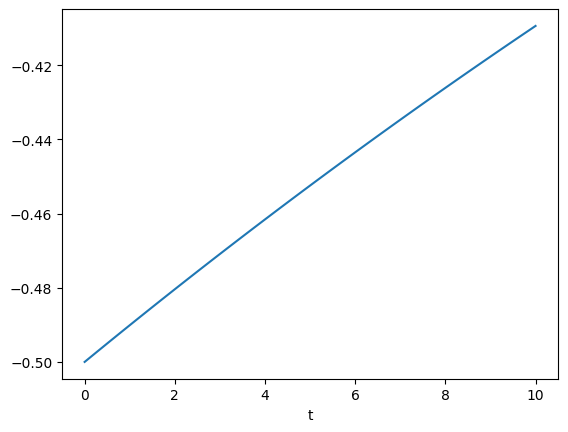

In [ ]:
# Plot exact observables

obs_index_exact = 0
plt.plot(ts_exact, observs_exact[obs_index_exact,:])
plt.xlabel('t')

## **Deterministic 1st Order Trotter**

In [ ]:
# Parameter choices (number of Trotter steps and repetitions)
r_det1 = 35
N_reps = 30

In [ ]:
# Run quantum trajectories
est_observs_det1, est_observs_std_det1 = trajectories_tebd1_obs(A_init, bond_dims, J, hs, t, r_det1, N_reps)

Repetition: 1/30
Repetition: 2/30
Repetition: 3/30
Repetition: 4/30
Repetition: 5/30
Repetition: 6/30
Repetition: 7/30
Repetition: 8/30
Repetition: 9/30
Repetition: 10/30
Repetition: 11/30
Repetition: 12/30
Repetition: 13/30
Repetition: 14/30
Repetition: 15/30
Repetition: 16/30
Repetition: 17/30
Repetition: 18/30
Repetition: 19/30
Repetition: 20/30
Repetition: 21/30
Repetition: 22/30
Repetition: 23/30
Repetition: 24/30
Repetition: 25/30
Repetition: 26/30
Repetition: 27/30
Repetition: 28/30
Repetition: 29/30
Repetition: 30/30


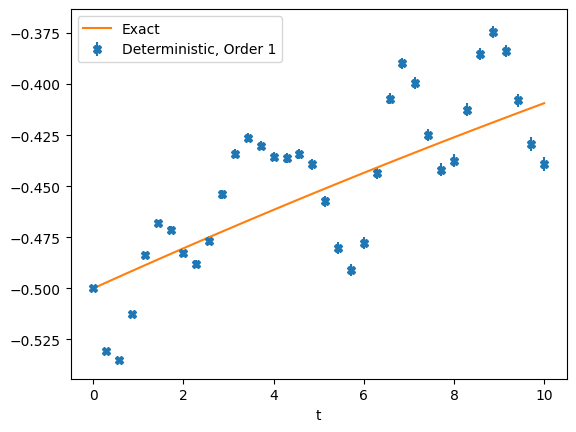

In [ ]:
# Plot observables
obs_index_det1 = 0
ts_det1 = np.linspace(0, t, r_det1+1)

plt.errorbar(ts_det1, np.real(est_observs_det1[obs_index_det1,:]), np.real(est_observs_std_det1[obs_index_det1,:]), fmt='X', label='Deterministic, Order 1')
plt.plot(ts_exact, observs_exact[obs_index_det1,:], label='Exact')
plt.xlabel('t')
plt.legend()

## **Deterministic 2nd Order Trotter**

In [ ]:
# Parameter choices (number of Trotter steps and repetitions)
r_det2 = 35
N_reps = 30

In [ ]:
# Run quantum trajectories
est_observs_det2, est_observs_std_det2 = trajectories_tebd2_obs(A_init, bond_dims, J, hs, t, r_det2, N_reps)

Repetition: 1/30
Repetition: 2/30
Repetition: 3/30
Repetition: 4/30
Repetition: 5/30
Repetition: 6/30
Repetition: 7/30
Repetition: 8/30
Repetition: 9/30
Repetition: 10/30
Repetition: 11/30
Repetition: 12/30
Repetition: 13/30
Repetition: 14/30
Repetition: 15/30
Repetition: 16/30
Repetition: 17/30
Repetition: 18/30
Repetition: 19/30
Repetition: 20/30
Repetition: 21/30
Repetition: 22/30
Repetition: 23/30
Repetition: 24/30
Repetition: 25/30
Repetition: 26/30
Repetition: 27/30
Repetition: 28/30
Repetition: 29/30
Repetition: 30/30


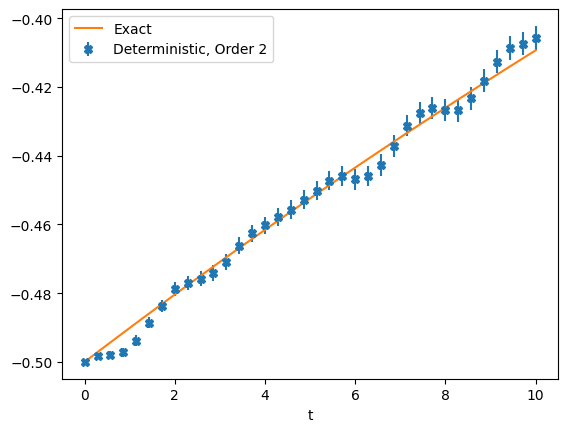

In [ ]:
# Plot observables
obs_index_det2 = 0
ts_det2 = np.linspace(0, t, r_det2+1)

plt.errorbar(ts_det2, np.real(est_observs_det2[obs_index_det2,:]), np.real(est_observs_std_det2[obs_index_det2,:]), fmt='X', label='Deterministic, Order 2')
plt.plot(ts_exact, observs_exact[obs_index_det2,:], label='Exact')
plt.xlabel('t')
plt.legend()

## **Deterministic 4th Order Trotter**

In [ ]:
# Parameter choices (number of Trotter steps and repetitions)
r_det4 = 7
N_reps = 30

In [ ]:
# Run quantum trajectories
est_observs_det4, est_observs_std_det4 = trajectories_tebd4_obs(A_init, bond_dims, J, hs, t, r_det4, N_reps)

Repetition: 1/30
Repetition: 2/30
Repetition: 3/30
Repetition: 4/30
Repetition: 5/30
Repetition: 6/30
Repetition: 7/30
Repetition: 8/30
Repetition: 9/30
Repetition: 10/30
Repetition: 11/30
Repetition: 12/30
Repetition: 13/30
Repetition: 14/30
Repetition: 15/30
Repetition: 16/30
Repetition: 17/30
Repetition: 18/30
Repetition: 19/30
Repetition: 20/30
Repetition: 21/30
Repetition: 22/30
Repetition: 23/30
Repetition: 24/30
Repetition: 25/30
Repetition: 26/30
Repetition: 27/30
Repetition: 28/30
Repetition: 29/30
Repetition: 30/30


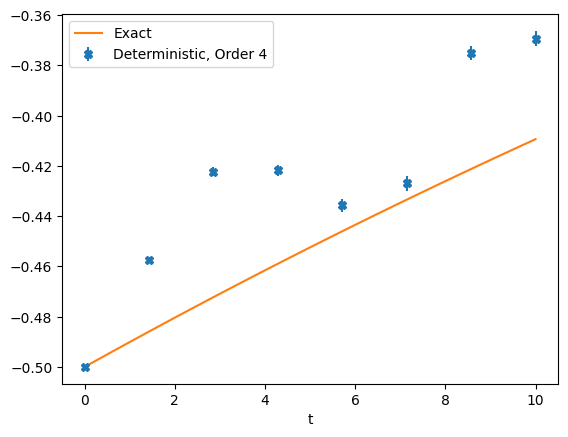

In [ ]:
# Plot observables
obs_index_det4 = 0
ts_det4 = np.linspace(0, t, r_det4+1)

plt.errorbar(ts_det4, np.real(est_observs_det4[obs_index_det4,:]), np.real(est_observs_std_det4[obs_index_det4,:]), fmt='X', label='Deterministic, Order 4')
plt.plot(ts_exact, observs_exact[obs_index_det4,:], label='Exact')
plt.xlabel('t')
plt.legend()

## **Randomly-Corrected Trotter, 2nd Order**

In [ ]:
# Determine correction terms for randomly-corrected 2nd order Trotterization

# The coefficient that arises in calculating commutators that comprise the correction terms
def coef(j):
  if j % 2 == 0:
    val=1
  if j % 2 == 1:
    val=2
  return val

# Create correction operations, which are expressed as a big sum of commutators
K2s = np.zeros((N-3, d**4, d**4), dtype=complex)
for j in range(N-3):
  tmp_j = np.kron(hs[j], np.identity(4))
  tmp_jPlus1 = np.kron(np.kron(np.identity(2), hs[j+1]), np.identity(2))
  tmp_jPlus2 = np.kron(np.identity(4), hs[j+2])
  tmp = comm(tmp_j + tmp_jPlus2, comm(tmp_j, tmp_jPlus1)) - comm(tmp_j + tmp_jPlus2, comm(tmp_jPlus1, tmp_jPlus2))
  K2 = -1/12*(-1)**j*coef(j)*tmp

  if j == 0:
    k=j-1
    tmp_kPlus1 = np.kron(hs[k+1], np.identity(4))
    tmp_kPlus2 = np.kron(np.kron(np.identity(2), hs[k+2]), np.identity(2))
    tmp = - comm(tmp_kPlus2, comm(tmp_kPlus1, tmp_kPlus2))
    K2 += -1/12*(-1)**k*coef(k)*tmp

  if j == N-4:
    k=j+1
    tmp_k = np.kron(np.kron(np.identity(2), hs[k]), np.identity(2))
    tmp_kPlus1 = np.kron(np.identity(4), hs[k+1])
    tmp = comm(tmp_k, comm(tmp_k, tmp_kPlus1))
    K2 += -1/12*(-1)**k*coef(k)*tmp

  K2s[j] = K2

In [ ]:
# Parameter choices (number of Trotter steps and repetitions)
r_corrected2 = 35
N_reps = 30

In [ ]:
# Run quantum trajectories
est_observs_corrected2, est_observs_std_corrected2 = trajectories_tebd2_corrected_obs(A_init, bond_dims, J, hs, K2s, t, r_corrected2, N_reps)

Repetition: 1/30
Repetition: 2/30
Repetition: 3/30
Repetition: 4/30
Repetition: 5/30
Repetition: 6/30
Repetition: 7/30
Repetition: 8/30
Repetition: 9/30
Repetition: 10/30
Repetition: 11/30
Repetition: 12/30
Repetition: 13/30
Repetition: 14/30
Repetition: 15/30
Repetition: 16/30
Repetition: 17/30
Repetition: 18/30
Repetition: 19/30
Repetition: 20/30
Repetition: 21/30
Repetition: 22/30
Repetition: 23/30
Repetition: 24/30
Repetition: 25/30
Repetition: 26/30
Repetition: 27/30
Repetition: 28/30
Repetition: 29/30
Repetition: 30/30


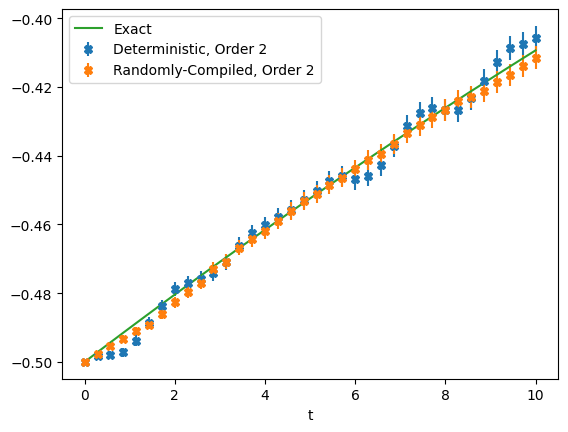

In [ ]:
# Plot observables, and compare to different Trotter schemes
obs_index = 0
ts_corrected2 = np.linspace(0, t, r_corrected2+1)

#plt.errorbar(ts_det1, np.real(est_observs_det1[obs_index,:]), np.real(est_observs_std_det1[obs_index,:]), fmt='X', label='Deterministic, Order 1')
#plt.plot(ts_det1, np.real(est_observs_det1[obs_index,:]), label='Deterministic, Order 1')

plt.errorbar(ts_det2, np.real(est_observs_det2[obs_index,:]), np.real(est_observs_std_det2[obs_index,:]), fmt='X', label='Deterministic, Order 2')
#plt.plot(ts_det2, np.real(est_observs_det2[obs_index,:]), label='Deterministic, Order 2')

#plt.errorbar(ts_det4, np.real(est_observs_det4[obs_index,:]), np.real(est_observs_std_det4[obs_index,:]), fmt='X', label='Deterministic, Order 4')
#plt.plot(ts_det4, np.real(est_observs_det4[obs_index,:]), label='Deterministic, Order 4')

plt.errorbar(ts_corrected2, np.real(est_observs_corrected2[obs_index,:]), np.real(est_observs_std_corrected2[obs_index,:]), fmt='X', label='Randomly-Compiled, Order 2')
#plt.plot(ts_corrected2, np.real(est_observs_corrected2[obs_index,:]), label='Randomly-Compiled, Order 2')

plt.plot(ts_exact, np.real(observs_exact[obs_index,:]), label='Exact')

plt.xlabel('t')
plt.legend()